## Import et chargement

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Options d'affichage
pd.set_option("display.max_columns", 8)
pd.set_option("display.max_rows", 8)

# Chargement des données
data = pd.read_excel("../data/Retail.xlsx")

# Copie de travail
df = data.copy()

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


# SQL E-commerce Analytics — Exploration des données

## 1. Présentation du dataset

Ce projet utilise le jeu de données **Online Retail**, issu du dépôt UCI.

Le dataset contient des transactions d'une entreprise britannique de vente en ligne sur la période 2010-2011.

L'objectif du projet est de préparer les données afin de pouvoir réaliser ensuite une analyse commerciale avec **Python/pandas**, puis **PostgreSQL/SQL** et enfin **Power BI**.

## 2. Première exploration des données

Le dataset contient des informations relatives aux transactions, aux produits, aux clients et aux pays.

Il ne possède pas de variable cible : il s'agit d'un jeu de données destiné à l'analyse descriptive et commerciale.

Avant toute transformation, l'objectif est de comprendre :
- la structure du dataset ;
- le type des variables ;
- les valeurs manquantes ;
- les éventuelles anomalies ;
- la structure des transactions.

In [2]:
print(f"Nombre de lignes : {df.shape[0]}")
print(f"Nombre de colonnes : {df.shape[1]}")

print("\nTypes des variables :")
print(df.dtypes)

print("\nValeurs manquantes :")
print(df.isna().sum())

Nombre de lignes : 541909
Nombre de colonnes : 8

Types des variables :
InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
UnitPrice             float64
CustomerID            float64
Country                object
dtype: object

Valeurs manquantes :
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64


In [3]:
summary = pd.DataFrame({"Type": df.dtypes, "% manquant": (df.isna().sum(axis=0))/df.shape[0],"Valeurs uniques": df.nunique()})
summary

,Type,% manquant,Valeurs uniques
InvoiceNo,object,0.000000,25900
StockCode,object,0.000000,4070
Description,object,0.002683,4223
Quantity,int64,0.000000,722
InvoiceDate,datetime64[ns],0.000000,23260
UnitPrice,float64,0.000000,1630
CustomerID,float64,0.249267,4372
Country,object,0.000000,38


## 3. Description des variables

| Variable | Description | Type logique |
|---|---|---|
| InvoiceNo | Numéro de facture | Identifiant |
| StockCode | Identifiant du produit | Identifiant |
| Description | Description du produit | Texte |
| Quantity | Quantité vendue | Numérique |
| InvoiceDate | Date et heure de la transaction | Date |
| UnitPrice | Prix unitaire | Numérique |
| CustomerID | Identifiant du client | Identifiant |
| Country | Pays du client | Catégoriel |

In [4]:
print(f"Produits uniques       : {df['StockCode'].nunique()}")
print(f"Clients uniques        : {df['CustomerID'].nunique()}")
print(f"Factures uniques       : {df['InvoiceNo'].nunique()}")
print(f"Descriptions uniques  : {df['Description'].nunique()}")
print(f"Pays uniques           : {df['Country'].nunique()}")

Produits uniques       : 4070
Clients uniques        : 4372
Factures uniques       : 25900
Descriptions uniques  : 4223
Pays uniques           : 38


### Observations

Le dataset contient :

- 4 070 références produit ;
- 4 372 clients identifiés ;
- 25 900 factures ;
- 4 223 descriptions différentes ;
- 38 pays.

Le nombre de factures est inférieur au nombre de lignes, ce qui indique qu'une facture peut contenir plusieurs lignes de produits.

Le nombre de descriptions est supérieur au nombre de références produit. Cette différence doit être interprétée avec prudence : certaines références sont associées à plusieurs descriptions, notamment en raison de commentaires ou d'anomalies opérationnelles présentes dans les données.

In [5]:
description_par_stock = (df.groupby("StockCode")["Description"].nunique().sort_values(ascending=False))
description_par_stock.head(5)

StockCode
20713     8
23084     7
21830     6
85175     6
72807A    5
Name: Description, dtype: int64

In [6]:
nb_stockcodes_multi_description = (description_par_stock > 1).sum()
print(f"{nb_stockcodes_multi_description} références produit ""sont associées à plusieurs descriptions.")

650 références produit sont associées à plusieurs descriptions.


In [7]:
df.loc[df["StockCode"] == 20713, "Description"].unique()

array(['JUMBO BAG OWLS', nan, 'wrongly marked. 23343 in box',
       'wrongly coded-23343', 'found', 'Found', 'wrongly marked 23343',
       'Marked as 23343', 'wrongly coded 23343'], dtype=object)

### Observation des références produits et de leurs descriptions

Certaines références produit sont associées à plusieurs descriptions.

L'exemple du `StockCode 20713` montre une description de produit normale :`JUMBO BAG OWLS` mais également plusieurs valeurs correspondant à des commentaires opérationnels tels que des erreurs de codage ou de marquage.

Cela indique que la colonne `Description` ne contient pas exclusivement des noms de produits.

Cette anomalie sera prise en compte lors de la phase de nettoyage. Il faudra notamment identifier les lignes correspondant à des opérations internes ou à des erreurs plutôt que de les considérer automatiquement comme des ventes normales.

In [8]:
df["IsCancellation"] = (df["InvoiceNo"].astype(str).str.startswith("C"))

print("Factures annulées :", df["IsCancellation"].sum())
print("Factures non annulées :", (~df["IsCancellation"]).sum())

Factures annulées : 9288
Factures non annulées : 532621


In [9]:
pd.crosstab(df["IsCancellation"],df["Quantity"] < 0)

Quantity,False,True
IsCancellation,,
False,531285,1336
True,0,9288


### Analyse des factures

9 288 lignes correspondent à des factures dont le numéro commence par `C`, ce qui indique une annulation.

La majorité des quantités négatives sont associées à ces factures annulées.

Cependant, 1 336 lignes présentent une quantité négative alors que leur numéro de facture ne commence pas par `C`.

L'analyse de ces lignes montre la présence de descriptions telles que `check`, `damaged`, `damages`, `stock check`, etc.

Ces transactions semblent correspondre à des ajustements ou opérations internes plutôt qu'à des ventes classiques.

Elles devront donc être étudiées avant de décider de leur traitement.

In [10]:
customer_missing = df["CustomerID"].isna()

print(f"Lignes sans CustomerID : {customer_missing.sum()}")
print(f"Pourcentage : {customer_missing.mean() * 100:.2f}%")
df.groupby(customer_missing).agg(nb_lignes=("InvoiceNo", "size"),nb_factures=("InvoiceNo", "nunique"),nb_produits=("StockCode", "nunique"))

Lignes sans CustomerID : 135080
Pourcentage : 24.93%


,nb_lignes,nb_factures,nb_produits
CustomerID,,,
False,406829,22190,3684
True,135080,3710,3810


### CustomerID manquant

Le dataset contient 135 080 lignes sans identifiant client, soit environ 25 % des observations.

L'absence de `CustomerID` ne signifie pas que la transaction est invalide : les autres informations de transaction peuvent être présentes.

Cependant, ces lignes ne peuvent pas être utilisées pour attribuer précisément les ventes à un client.

La décision de conservation ou d'exclusion dépendra donc de l'analyse réalisée :

- pour le chiffre d'affaires global, ces transactions peuvent être conservées ;
- pour l'analyse du comportement ou du chiffre d'affaires par client, elles ne peuvent pas être attribuées à un client identifié.

Les valeurs manquantes de `CustomerID` seront donc conservées dans un premier temps.

In [11]:
print(f"Descriptions manquantes : {df['Description'].isna().sum()}")
df[df["Description"].isna()].head()

Descriptions manquantes : 1454


,InvoiceNo,StockCode,Description,Quantity,...,UnitPrice,CustomerID,Country,IsCancellation
622,536414,22139,NaN,56,...,0.0,NaN,United Kingdom,False
1970,536545,21134,NaN,1,...,0.0,NaN,United Kingdom,False
1971,536546,22145,NaN,1,...,0.0,NaN,United Kingdom,False
1972,536547,37509,NaN,1,...,0.0,NaN,United Kingdom,False
1987,536549,85226A,NaN,1,...,0.0,NaN,United Kingdom,False


In [12]:
df.groupby(df["Description"].isna())["UnitPrice"].agg(["count", "mean", "median", "sum"])

,count,mean,median,sum
Description,,,,
False,540455,4.623519,2.08,2498803.974
True,1454,0.000000,0.00,0.000


### Description manquante

1 454 lignes manquent de description du produit.

On voit que ces lignes présentent un montant de vente nul.

Ces observations ne contribuent donc pas au chiffre d'affaires dans l'état actuel des données.

La variable `Description` n'étant par ailleurs pas indispensable au calcul des ventes lorsque `StockCode`, `Quantity` et `UnitPrice` sont disponibles, ces lignes sont conservées dans un premier temps afin d'éviter une suppression prématurée.

In [13]:
df[["Quantity", "UnitPrice"]].describe()

,Quantity,UnitPrice
count,541909.000000,541909.000000
mean,9.552250,4.611114
std,218.081158,96.759853
min,-80995.000000,-11062.060000
25%,1.000000,1.250000
50%,3.000000,2.080000
75%,10.000000,4.130000
max,80995.000000,38970.000000


In [14]:
print("Quantités négatives :", (df["Quantity"] < 0).sum())
print("Prix nuls :", (df["UnitPrice"] == 0).sum())
print("Prix négatifs :", (df["UnitPrice"] < 0).sum())

Quantités négatives : 10624
Prix nuls : 2515
Prix négatifs : 2


In [15]:
df[df["UnitPrice"] < 0]

,InvoiceNo,StockCode,Description,Quantity,...,UnitPrice,CustomerID,Country,IsCancellation
299983,A563186,B,Adjust bad debt,1,...,-11062.06,NaN,United Kingdom,False
299984,A563187,B,Adjust bad debt,1,...,-11062.06,NaN,United Kingdom,False


## Analyse des variables numériques de quantité et de prix

L'analyse descriptive met en évidence plusieurs valeurs atypiques.

La variable `Quantity` présente une moyenne de 9,55 unités, mais une médiane de seulement 3 unités. L'écart important entre ces deux valeurs s'explique notamment par la présence de quantités extrêmement élevées, avec un maximum de 80 995 unités.

La variable `UnitPrice` présente également une forte dispersion : la médiane est de 2,08 alors que la moyenne atteint 4,61. Le prix maximum atteint 38 970, ce qui indique la présence de valeurs extrêmes.

Par ailleurs :

- 10 624 lignes présentent une quantité négative ;
- 2 515 lignes présentent un prix unitaire nul ;
- 2 lignes présentent un prix unitaire négatif.

Les valeurs négatives de `Quantity` sont principalement associées aux annulations, mais certaines correspondent également à des opérations ou ajustements internes.

Deux observations présentent un `UnitPrice` négatif.

Ces observations sont des cas isolés et ne correspondent pas à une vente classique. Elles seront donc considérées comme des anomalies de données et feront l'objet d'un traitement spécifique lors du nettoyage.

Compte tenu de leur très faible nombre, leur impact sur l'analyse globale est limité.

In [16]:
lignes_par_invoice = df.groupby("InvoiceNo").size()
lignes_par_invoice.describe()

count    25900.000000
mean        20.923127
std         43.031334
min          1.000000
25%          2.000000
50%         10.000000
75%         23.000000
max       1114.000000
dtype: float64

### Structure des factures

Le dataset contient 25 900 factures pour 541 909 lignes de transaction.

Le nombre de lignes étant largement supérieur au nombre de factures, une facture peut contenir plusieurs lignes correspondant à différents produits.

L'analyse du nombre de lignes par facture permet de mieux comprendre la structure transactionnelle du dataset.

In [17]:
ord_par_customer = ( df.dropna(subset=["CustomerID"]).groupby("CustomerID")["InvoiceNo"].nunique())

In [18]:
ord_par_customer.describe()

count    4372.000000
mean        5.075480
std         9.338754
min         1.000000
25%         1.000000
50%         3.000000
75%         5.000000
max       248.000000
Name: InvoiceNo, dtype: float64

### Analyse des clients

Le dataset contient 4 372 clients identifiés.

Le nombre de commandes par client est calculé à partir du nombre de `InvoiceNo` distincts associés à chaque `CustomerID`.

Cette analyse permet d'identifier les clients les plus actifs et de mesurer la fréquence d'achat.

Les observations sans `CustomerID` sont exclues de cette analyse spécifique car elles ne peuvent pas être attribuées à un client identifié.

## Création de la variable Sales

Afin de permettre une analyse commerciale, une nouvelle variable `Sales` est créée selon la formule :

`Sales = Quantity × UnitPrice`

Cette variable représente le montant associé à chaque ligne de transaction.

À ce stade, il s'agit d'un chiffre d'affaires brut. Il inclut notamment les annulations, les retours et certaines opérations particulières identifiées lors de l'exploration.

Le chiffre d'affaires définitif sera calculé après le nettoyage des données.

In [19]:
df["Sales"]=df["Quantity"]*df["UnitPrice"]

In [20]:
df["Sales"].describe()

count    541909.000000
mean         17.987795
std         378.810824
min     -168469.600000
25%           3.400000
50%           9.750000
75%          17.400000
max      168469.600000
Name: Sales, dtype: float64

In [21]:
print(f"Chiffre d'affaires brut : {df['Sales'].sum()} sterling")
print(f"Chiffre d'affaires positifs : {df[df['Sales']>0]['Sales'].sum()} sterling")
print(f"Chiffre d'affaires négatifs : {df[df['Sales']<0]['Sales'].sum()} sterling")

Chiffre d'affaires brut : 9747747.933999998 sterling
Chiffre d'affaires positifs : 10666684.544 sterling
Chiffre d'affaires négatifs : -918936.6099999999 sterling


### Analyse du chiffre d'affaires

L'analyse du chiffre d'affaires brut permet de constater que les données contiennent à la fois des montants positifs et négatifs.

Les montants positifs correspondent principalement aux ventes, tandis que les montants négatifs sont principalement liés aux retours, annulations ou ajustements.

Il est donc nécessaire de distinguer ces différentes situations avant de produire des indicateurs commerciaux définitifs.

In [22]:
country_sales = (df.groupby("Country")["Sales"] .sum() .sort_values(ascending=False))
somme=df["Sales"].sum()
print(country_sales/somme)

Country
United Kingdom    0.839969
Netherlands       0.029203
EIRE              0.027009
Germany           0.022744
                    ...   
RSA               0.000103
Czech Republic    0.000073
Bahrain           0.000056
Saudi Arabia      0.000013
Name: Sales, Length: 38, dtype: float64


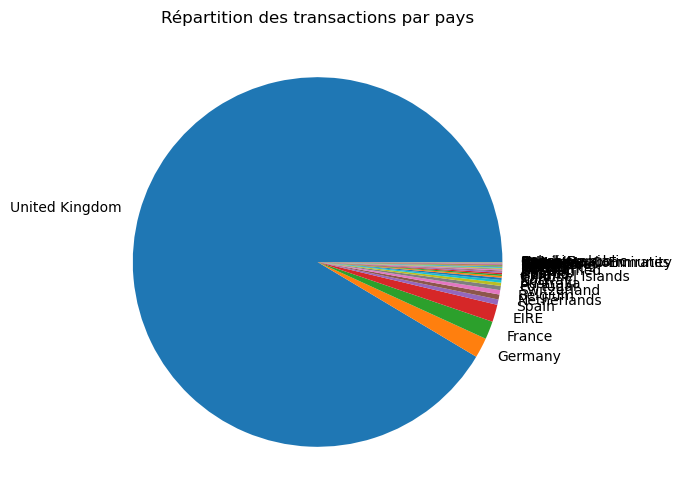

In [23]:
plt.figure(figsize=(6, 6))

df["Country"].value_counts().plot.pie()

plt.title("Répartition des transactions par pays")
plt.ylabel("")
plt.show()

## Analyse géographique

Le dataset contient 38 pays.

La majorité des transactions est réalisée au Royaume-Uni, ce qui est cohérent avec le fait que l'entreprise étudiée est une entreprise britannique.

Le Royaume-Uni représente donc la principale zone géographique du dataset.

Une analyse complémentaire du chiffre d'affaires par pays permet de mesurer la contribution économique de chaque marché.

In [24]:
print("Date minimum :", df["InvoiceDate"].min())
print("Date maximum :", df["InvoiceDate"].max())

Date minimum : 2010-12-01 08:26:00
Date maximum : 2011-12-09 12:50:00


In [25]:
df["YearMonth"] = df["InvoiceDate"].dt.to_period("M")

monthly_sales = (df.groupby("YearMonth")["Sales"].sum())

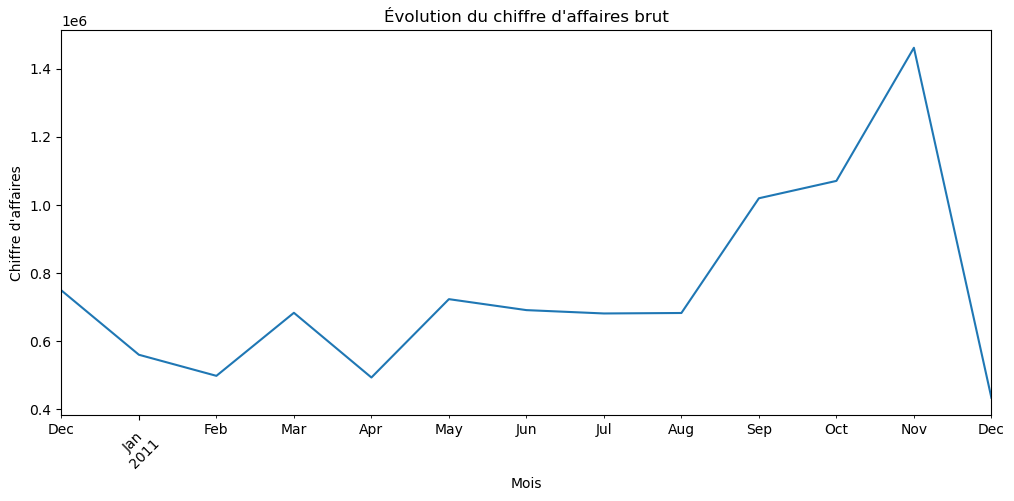

In [26]:
plt.figure(figsize=(12, 5))

monthly_sales.plot()

plt.title("Évolution du chiffre d'affaires brut")
plt.xlabel("Mois")
plt.ylabel("Chiffre d'affaires")
plt.xticks(rotation=45)

plt.show()

La variable `InvoiceDate` permet d'étudier l'évolution de l'activité dans le temps.

La période couverte par le dataset s'étend de décembre 2010 à décembre 2011.

Une agrégation mensuelle du chiffre d'affaires permet d'observer les variations de l'activité commerciale au cours de la période.

Cette dimension temporelle sera particulièrement importante lors de la construction du dashboard Power BI et permettra notamment de créer des indicateurs d'évolution et de comparaison entre périodes.

#  Conclusion de l'exploration

L'exploration initiale du dataset a permis d'identifier sa structure ainsi que plusieurs problèmes de qualité des données.

Le dataset contient 541 909 lignes et 8 variables, correspondant à des transactions commerciales.

Les principales observations sont les suivantes :

- 4 070 références produit ;
- 4 372 clients identifiés ;
- 25 900 factures ;
- 38 pays ;
- 1 454 descriptions manquantes ;
- 135 080 `CustomerID` manquants ;
- 9 288 factures identifiées comme annulations ;
- 10 624 quantités négatives ;
- 2 515 prix nuls ;
- 2 prix négatifs.

Plusieurs anomalies ont également été identifiées dans la colonne `Description`, avec certaines références produit associées à plusieurs descriptions ou à des commentaires opérationnels.

L'analyse a également montré qu'une facture peut contenir plusieurs lignes de produits et qu'un client peut effectuer plusieurs commandes.

Enfin, la création de la variable `Sales = Quantity × UnitPrice` permet de préparer les futures analyses commerciales.

## Principaux points à traiter lors du nettoyage

1. Traiter les valeurs manquantes de `CustomerID`.
2. Traiter les descriptions manquantes.
3. Identifier et traiter les factures annulées.
4. Examiner les quantités négatives.
5. Traiter les prix nuls et négatifs.
6. Examiner les anomalies de description.
7. Vérifier les éventuels doublons.
8. Vérifier et corriger les types de données si nécessaire.
9. Valider les données après nettoyage.

L'objectif de la prochaine étape sera de transformer ce dataset brut en un dataset fiable et cohérent pour l'analyse commerciale, avant son exploitation avec PostgreSQL et SQL.

# 3. Nettoyage des données

In [27]:
df_clean=data.copy()

In [28]:
df_clean["InvoiceNo"] = df_clean["InvoiceNo"].astype("string")
df_clean["CustomerID"] = df_clean["CustomerID"].astype("Int64").astype("string")
df_clean["StockCode"] = df_clean["StockCode"].astype("string")

Les colonnes `InvoiceNo`, `CustomerID` et `StockCode` représentent des identifiants et non des variables quantitatives.

Elles sont donc converties en type texte.

Cette transformation est particulièrement importante pour `InvoiceNo`, car certaines factures commencent par la lettre `C`.

`CustomerID` était initialement de type `float64`, notamment en raison de la présence de valeurs manquantes. Il est converti en entier nullable puis en texte afin de conserver les identifiants sans décimales tout en préservant les valeurs manquantes.

Les valeurs manquantes de `CustomerID` sont conservées à ce stade. Elles seront traitées comme des clients non identifiés plutôt que supprimées, car les autres informations transactionnelles restent exploitables.

## Traitement des valeurs manquantes

### CustomerID

L'exploration a identifié 135 080 valeurs manquantes dans `CustomerID`.

Ces observations ne sont pas supprimées car elles contiennent néanmoins des informations transactionnelles importantes : facture, produit, quantité, prix, date et pays.

Les transactions sans identifiant client sont donc conservées pour les analyses globales et commerciales.

En revanche, elles ne pourront pas être utilisées dans les analyses nécessitant l'identification individuelle d'un client.

Les valeurs manquantes sont conservées sous forme de valeurs nulles plutôt que remplacées par une valeur artificielle telle que `"Inconnu"`, afin de ne pas créer un faux client.

### Description

1 454 observations présentent une description manquante.

L'analyse exploratoire a montré que ces 1 454 observations présentent toutes un `UnitPrice` égal à zéro.

La variable `Description` constitue une information descriptive du produit mais n'est pas indispensable aux calculs transactionnels lorsque `StockCode`, `Quantity` et `UnitPrice` sont disponibles.

Ces observations sont donc conservées afin d'éviter une perte inutile de données.

Les valeurs manquantes pourront éventuellement être représentées comme `"Inconnu"` lors de certaines visualisations, notamment dans Power BI, sans modifier la donnée source.

In [29]:
df_clean = df_clean[df_clean["UnitPrice"] >= 0].copy()

In [30]:
df_clean["IsCancellation"] = (df_clean["InvoiceNo"].str.startswith("C"))

L'exploration a montré que 9 288 factures commencent par la lettre `C`.

Ces factures correspondent aux transactions identifiées comme des annulations.

Plutôt que de supprimer immédiatement ces observations, une variable indicatrice `IsCancellation` est créée.

Cette approche permet de conserver l'information sur les retours ou annulations et de les distinguer des ventes normales lors des analyses commerciales.

Les annulations pourront ainsi être utilisées pour calculer ultérieurement des ventes nettes.

In [31]:
## Création d'une catégorie ->vente, annulation ou operation interne/ajustement/anomalies
df_clean["Transaction_Type"]="Sale"
df_clean.loc[df_clean["IsCancellation"], ["Transaction_Type"]]="Cancellation"
df_clean.loc[(~df_clean["IsCancellation"]) & (df_clean["Quantity"]<0),["Transaction_Type"]]="Adjustment"

L'exploration a montré que les quantités négatives ne correspondent pas toutes au même phénomène.

Les factures commençant par `C` sont identifiées comme des annulations.

Certaines quantités négatives ne sont cependant pas associées à une facture `C`. L'analyse de leurs descriptions a notamment révélé des termes tels que `check`, `damaged`, `damages` ou `stock check`, suggérant des opérations internes ou des ajustements.

Une variable `Transaction_Type` est donc créée afin de distinguer trois catégories :

- `Sale` : transaction positive classique ;
- `Cancellation` : facture identifiée par le préfixe `C` ;
- `Adjustment` : quantité négative sans facture `C`.

Cette classification permet de conserver les observations tout en les distinguant pour les futures analyses.

### Analyse des prix unitaires nuls

2 515 observations présentent un `UnitPrice` égal à zéro.

Certaines correspondent à des opérations particulières ou internes, avec des descriptions telles que `check`, `found` ou `adjustment`. D'autres présentent néanmoins des descriptions correspondant à de véritables produits.

On remarque aussi que les 1 454 descriptions manquantes ont toutes UnitPrice = 0 (voir crosstab) , et qu'on a des quantités <0 et >0 associées aux UnitPrice

Il n'est donc pas pertinent de supprimer automatiquement toutes les lignes dont le prix unitaire est nul.

Les deux observations présentant un `UnitPrice` négatif constituent en revanche des anomalies isolées et ont été supprimées du dataset analytique.

In [32]:
df_clean[df_clean["UnitPrice"] == 0][ ["InvoiceNo", "StockCode", "Description",
     "Quantity", "CustomerID", "Country"]].head(5)

,InvoiceNo,StockCode,Description,Quantity,CustomerID,Country
622,536414,22139,NaN,56,<NA>,United Kingdom
1970,536545,21134,NaN,1,<NA>,United Kingdom
1971,536546,22145,NaN,1,<NA>,United Kingdom
1972,536547,37509,NaN,1,<NA>,United Kingdom
1987,536549,85226A,NaN,1,<NA>,United Kingdom


In [33]:
pd.crosstab( df_clean["UnitPrice"] == 0, df_clean["Quantity"] < 0)

Quantity,False,True
UnitPrice,,
False,530104,9288
True,1179,1336


In [34]:
pd.crosstab(df_clean["UnitPrice"] == 0,df_clean["Description"].isna())

Description,False,True
UnitPrice,,
False,539392,0
True,1061,1454


In [35]:
df_clean.loc[df_clean["UnitPrice"] == 0,"Description"].value_counts(dropna=False).head(30)

Description
NaN                              1454
check                             159
?                                  47
damages                            45
                                 ... 
dotcom                              6
Manual                              6
FRENCH BLUE METAL DOOR SIGN 9       6
FRENCH BLUE METAL DOOR SIGN 7       6
Name: count, Length: 30, dtype: int64

## Traitement des doublons

L'exploration du dataset nettoyé révèle 5 268 lignes entièrement dupliquées.

L'inspection de plusieurs exemples montre que certaines lignes sont strictement identiques sur l'ensemble des variables.

Ces duplications peuvent entraîner une surestimation artificielle du nombre de transactions et du chiffre d'affaires.

Les doublons exacts sont donc supprimés afin que chaque observation identique ne soit comptabilisée qu'une seule fois.

In [36]:
print("Nombre de lignes dupliquées :", df_clean.duplicated().sum())

Nombre de lignes dupliquées : 5268


In [37]:
df_clean[df_clean.duplicated(keep=False)].sort_values(by=["InvoiceNo", "StockCode"]).head(5)

,InvoiceNo,StockCode,Description,Quantity,...,CustomerID,Country,IsCancellation,Transaction_Type
494,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,...,17908,United Kingdom,False,Sale
517,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,...,17908,United Kingdom,False,Sale
485,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,...,17908,United Kingdom,False,Sale
539,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,...,17908,United Kingdom,False,Sale
489,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,...,17908,United Kingdom,False,Sale


In [38]:
df_clean = df_clean.drop_duplicates().copy()

## Vérification des quantités nulles

L'exploration et le contrôle des données montrent qu'aucune observation ne présente une quantité égale à zéro.

Aucune suppression ou transformation n'est donc nécessaire pour cette variable.

Les quantités négatives sont conservées car elles ont déjà été identifiées comme des annulations ou des ajustements selon le contexte de la transaction.

## Variable Sales

Une nouvelle variable `Sales` est créée afin de représenter le montant associé à chaque ligne de transaction.

La formule utilisée est :

`Sales = Quantity × UnitPrice`

Les transactions positives génèrent des montants positifs.

Les retours ou annulations associés à des quantités négatives génèrent des montants négatifs et pourront ainsi être pris en compte dans le calcul des ventes nettes.

Les transactions avec `UnitPrice = 0` génèrent un montant nul mais restent conservées dans le dataset.

In [39]:
df_clean["Sales"] = (df_clean["Quantity"] * df_clean["UnitPrice"])

## Validation finale

Une série de contrôles est réalisée afin de vérifier que les transformations ont été correctement appliquées et que le dataset est cohérent après nettoyage.

In [40]:
print("===== VALIDATION DU DATASET =====")

print("\nDimensions :", df_clean.shape)

print("\nValeurs manquantes :")
print(df_clean.isna().sum())

print("\nDoublons :", df_clean.duplicated().sum())

print("\nPrix négatifs :", (df_clean["UnitPrice"] < 0).sum())

print("\nQuantités nulles :", (df_clean["Quantity"] == 0).sum())

print("\nQuantités négatives :", (df_clean["Quantity"] < 0).sum())

print("\nTypes :")
print(df_clean.dtypes)

===== VALIDATION DU DATASET =====

Dimensions : (536639, 11)

Valeurs manquantes :
InvoiceNo              0
StockCode              0
Description         1454
Quantity               0
                    ... 
Country                0
IsCancellation         0
Transaction_Type       0
Sales                  0
Length: 11, dtype: int64

Doublons : 0

Prix négatifs : 0

Quantités nulles : 0

Quantités négatives : 10587

Types :
InvoiceNo           string[python]
StockCode           string[python]
Description                 object
Quantity                     int64
                         ...      
Country                     object
IsCancellation             boolean
Transaction_Type            object
Sales                      float64
Length: 11, dtype: object


## Synthèse des traitements

| Problème identifié | Traitement |
|---|---|
| `InvoiceNo` de type objet | Conversion en texte |
| `StockCode` de type objet | Conservation / conversion en texte |
| `CustomerID` de type `float64` | Conversion en identifiant texte nullable |
| `CustomerID` manquant | Conservation |
| `Description` manquante | Conservation |
| `UnitPrice < 0` | Suppression des 2 anomalies |
| `UnitPrice = 0` | Conservation après analyse |
| Factures commençant par `C` | Conservation + identification comme annulations |
| `Quantity < 0` avec facture `C` | Classification `Cancellation` |
| `Quantity < 0` sans facture `C` | Classification `Adjustment` |
| Doublons exacts | Suppression des 5 268 doublons |
| `Quantity = 0` | Aucun cas détecté |
| `Quantity < 0` | Conservation et classification |
| `Sales` | Création à partir de `Quantity × UnitPrice` |

Le dataset nettoyé est maintenant prêt pour la phase d'analyse commerciale et pour son exploitation ultérieure avec SQL et Power BI.

In [41]:
df_clean.to_csv("../data/online_retail_clean.csv", index=False)

## Partie Compréhension Bonus

In [42]:
# Ventes positives
sales = df_clean[(~df_clean["IsCancellation"]) & (df_clean["Quantity"] > 0)]

# Annulations
cancellations = df_clean[df_clean["IsCancellation"]].copy()

# Recherche d'une vente correspondant au même produit, prix et quantité opposée
sales_keys = set(zip(sales["StockCode"],sales["UnitPrice"],-sales["Quantity"]))

cancellations["Has_Matching_Sale"] = cancellations.apply(lambda row: (row["StockCode"],row["UnitPrice"],row["Quantity"]) in sales_keys,axis=1)

print(cancellations["Has_Matching_Sale"].value_counts())
print(cancellations["Has_Matching_Sale"].value_counts(normalize=True) * 100)

Has_Matching_Sale
True     7464
False    1787
Name: count, dtype: int64
Has_Matching_Sale
True     80.683169
False    19.316831
Name: proportion, dtype: float64


### Vérification des annulations

Les transactions identifiées comme des annulations sont comparées aux ventes positives afin de vérifier si une transaction présentant le même produit, le même prix et une quantité opposée peut être retrouvée.

Sur les 9 251 annulations conservées après le nettoyage, **7 464 (80,7 %) présentent une vente positive compatible**, tandis que **1 787 (19,3 %) ne présentent pas de correspondance exacte** selon ces critères.

Cette analyse ne permet pas d'affirmer qu'une vente correspondante est nécessairement la transaction initialement annulée. Elle permet uniquement d'identifier une correspondance possible dans les données.

Les annulations sont donc conservées dans le dataset et leurs montants négatifs sont maintenus dans la variable `Sales`. Cela permettra de distinguer les ventes brutes des ventes nettes lors des analyses ultérieures.


In [43]:
pd.set_option("display.max_columns", 11)
df_clean

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,IsCancellation,Transaction_Type,Sales
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,False,Sale,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,False,Sale,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,False,Sale,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,False,Sale,20.34
...,...,...,...,...,...,...,...,...,...,...,...
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680,France,False,Sale,12.60
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680,France,False,Sale,16.60
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680,France,False,Sale,16.60
541908,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,12680,France,False,Sale,14.85


In [64]:

df_clean[df_clean["Transaction_Type"] == "Sale"].groupby("StockCode")["Sales"] \
    .sum() \
    .sort_values(ascending=False)

StockCode
DOT       206248.77
22423     174156.54
23843     168469.60
85123A    104462.75
            ...    
35951          0.00
62095B         0.00
85044          0.00
23595          0.00
Name: Sales, Length: 3941, dtype: float64